Decision Tree Classifier — Breast Cancer Wisconsin



In [4]:
import pandas as pd  # For Reading the data
import numpy as np
from sklearn.tree import DecisionTreeClassifier  # To build our Decision tree
from sklearn.tree import plot_tree  # To show the tree
from sklearn.model_selection import train_test_split  # To split the data for testing and training
from sklearn.model_selection import cross_val_score  # To perform a K-fold Cross validation (K = 5 for SciKitLearn)
from sklearn.metrics import confusion_matrix  # To build a confusion matrix for our tree
from sklearn.metrics import ConfusionMatrixDisplay  # To plot the confusion matrix
import matplotlib.pyplot as plt

RANDOM_STATE=42
CV_FOLDS=5


Load & Explore Data


In [5]:
# Breast Cancer Wisconsin (Diagnostic) — read with pandas
url=(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/"
    "breast-cancer-wisconsin/wdbc.data")
df=pd.read_csv(url, header=None)

df.columns=["id", "diagnosis"] + [f"feature_{i}" for i in range(1, 31)]
df["target"]=df["diagnosis"].map({"M": 0, "B": 1})  # 0 = malignant, 1 = benign

print(df.shape)
print(df["diagnosis"].value_counts())
df.head()


(569, 33)
diagnosis
B    357
M    212
Name: count, dtype: int64


,id,diagnosis,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,feature_30,target
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
feature = [c for c in df.columns if c.startswith("feature_")]
X=df[feature].values
y=df["target"].values
class_names = ["malignant", "benign"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE,stratify=y)



Train a Decision Tree gini


In [7]:
tree=DecisionTreeClassifier(random_state=RANDOM_STATE,criterion='gini')
tree.fit(X_train, y_train)

train_acc=tree.score(X_train, y_train)
test_acc=tree.score(X_test, y_test)
cv_scores=cross_val_score(tree, X_train, y_train, cv=CV_FOLDS)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"CV accuracy (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Train accuracy: 1.0000
Test accuracy: 0.9123
CV accuracy (5-fold): 0.9099 (+/- 0.0189)


Visualize the Tree


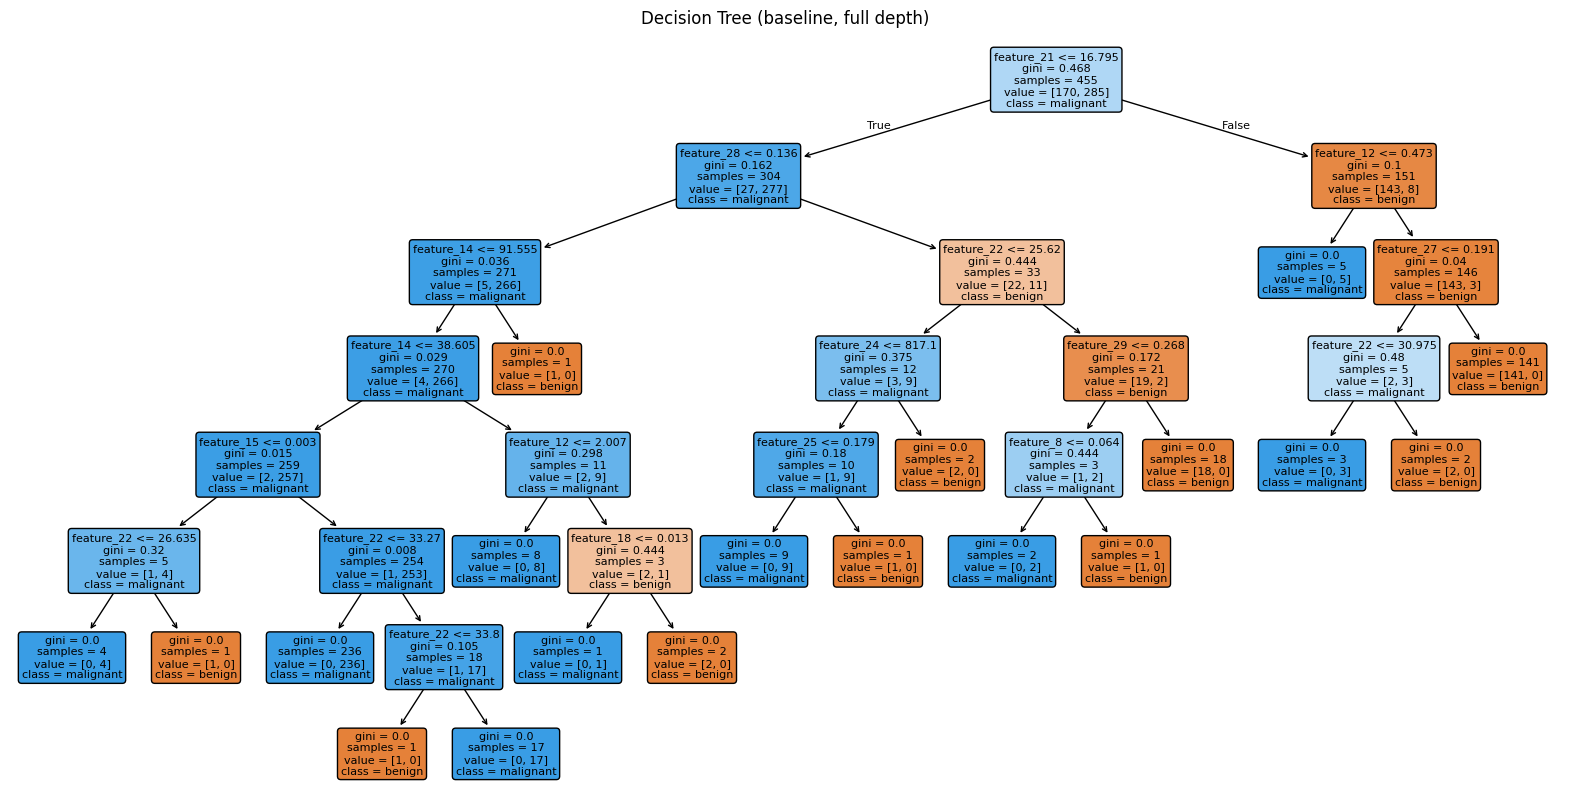

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(tree,feature_names=feature,class_names=['benign', 'malignant'],filled=True,rounded=True,fontsize=8)
plt.title("Decision Tree (baseline, full depth)")
plt.show()


Confusion Matrix (test set)


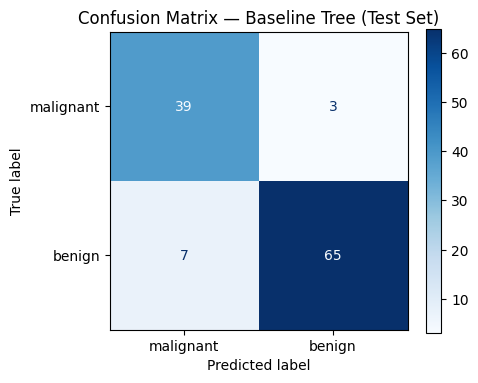

Confusion matrix:
 [[39  3]
 [ 7 65]]


In [9]:
y_pred=tree.predict(X_test)
cm=confusion_matrix(y_test,y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — Baseline Tree (Test Set)")
plt.tight_layout()
plt.show()

print("Confusion matrix:\n", cm)


Now changing the default tree loss from gini to entropyy


In [10]:
dt_entropy=tree=DecisionTreeClassifier(random_state=RANDOM_STATE,criterion='entropy')
tree.fit(X_train, y_train)

train_acc=dt_entropy.score(X_train, y_train)
test_acc=dt_entropy.score(X_test, y_test)
cv_scores=cross_val_score(dt_entropy, X_train, y_train, cv=CV_FOLDS)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"CV accuracy (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


Train accuracy: 1.0000
Test accuracy: 0.9123
CV accuracy (5-fold): 0.9319 (+/- 0.0128)


Visualising the entropy tree

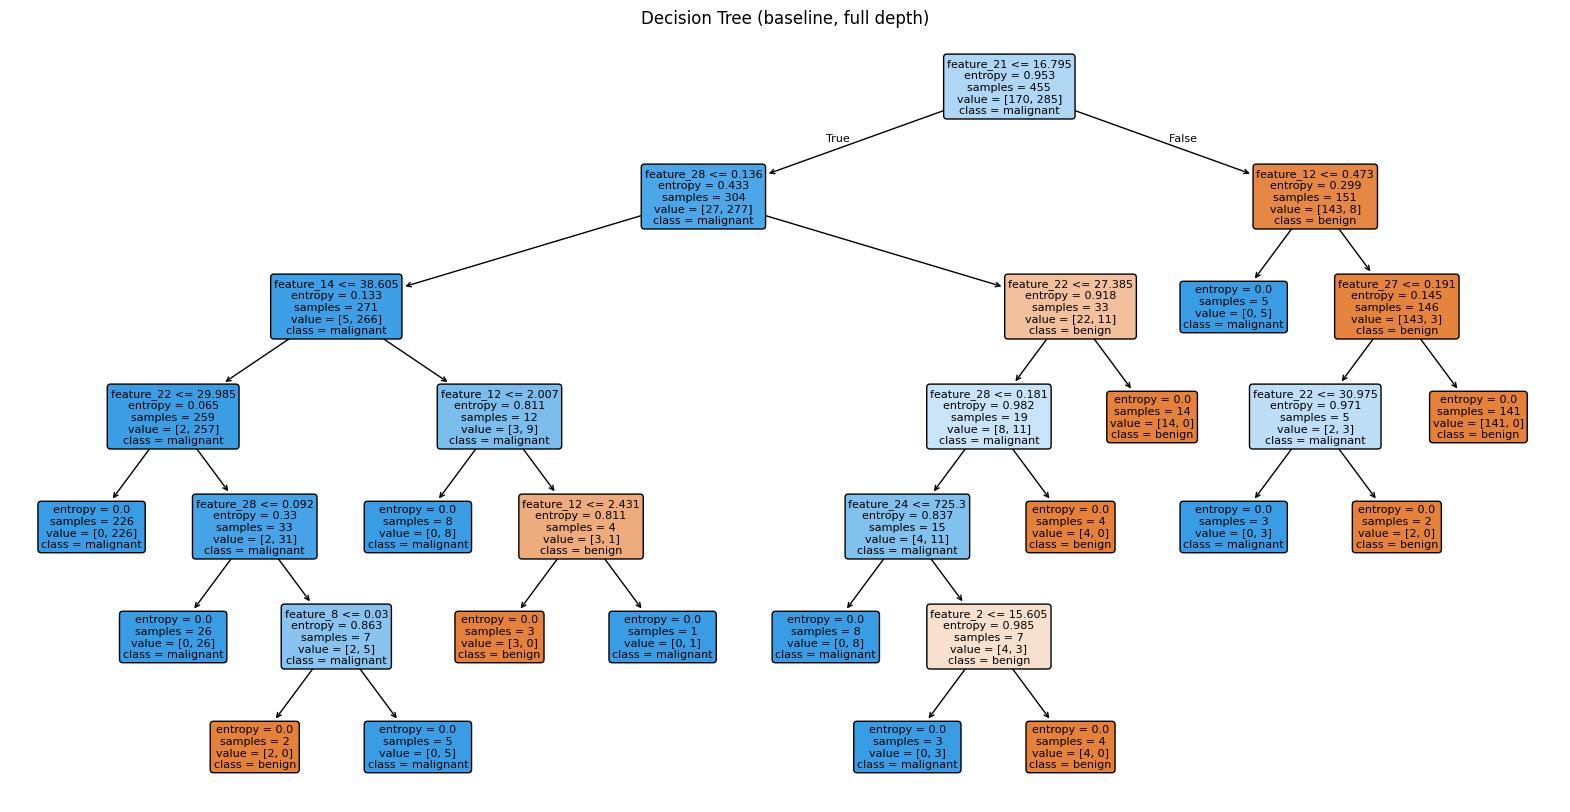

In [11]:
plt.figure(figsize=(20, 10))
plot_tree(dt_entropy,feature_names=feature,class_names=['benign', 'malignant'],filled=True,rounded=True,fontsize=8)
plt.title("Decision Tree (baseline, full depth)")
plt.show()

confusion matrix of entropy

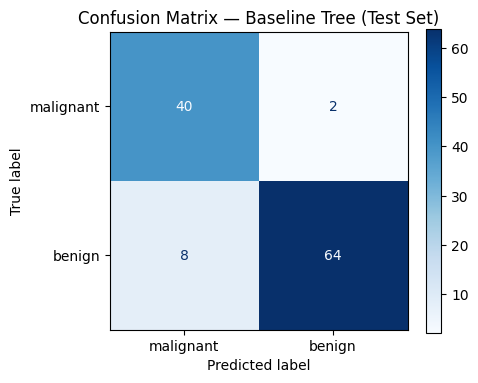

Confusion matrix:
 [[40  2]
 [ 8 64]]


In [12]:
y_pred_entropy=tree.predict(X_test)
cm_entropy=confusion_matrix(y_test,y_pred_entropy)

fig,ax=plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_entropy,display_labels=class_names).plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — Baseline Tree (Test Set)")
plt.tight_layout()
plt.show()

print("Confusion matrix:\n", cm_entropy)

since entropy has a better cv accuracy it is the better model for this problem

Hyperparameter Comparison (one at a time)




In [13]:
def log_loss_from_proba(y_true,y_proba):
    y_true=np.asarray(y_true)
    p=y_proba[np.arange(len(y_true)), y_true]
    return -np.mean(np.log(p + 1e-15))


def evaluate_hyperparameter(param_name,param_values,x_labels=None):
    rows=[]
    for value in param_values:
        params={param_name:value,"random_state":RANDOM_STATE}
        clf=DecisionTreeClassifier(**params)

        val_acc_scores=cross_val_score(clf,X_train,y_train,cv=CV_FOLDS,scoring="accuracy")
        val_ll_scores=cross_val_score(clf,X_train,y_train,cv=CV_FOLDS,scoring="neg_log_loss")

        clf.fit(X_train,y_train)
        train_proba = clf.predict_proba(X_train)

        rows.append({param_name:value,"train_accuracy":clf.score(X_train, y_train),"val_accuracy": val_acc_scores.mean(),"val_accuracy_std": val_acc_scores.std(),"train_log_loss": log_loss_from_proba(y_train, train_proba),"val_log_loss": -val_ll_scores.mean(),"val_log_loss_std": val_ll_scores.std(),})

    return pd.DataFrame(rows),x_labels


def plot_hyperparameter_results(df,param_name,title):
    fig,axes=plt.subplots(1,2,figsize=(10,4))
    fig.suptitle(title)
    axes[0].plot(df[param_name],df["train_accuracy"],marker="o",label="Train")
    axes[0].plot(df[param_name],df["val_accuracy"],marker="s",label="Validation")
    axes[0].set_xlabel(param_name)
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[1].plot(df[param_name],df["train_log_loss"],marker="o",label="Train")
    axes[1].plot(df[param_name],df["val_log_loss"],marker="s",label="Validation")
    axes[1].set_xlabel(param_name)
    axes[1].set_ylabel("Log Loss")
    axes[1].legend()
    plt.show()


Max Depth


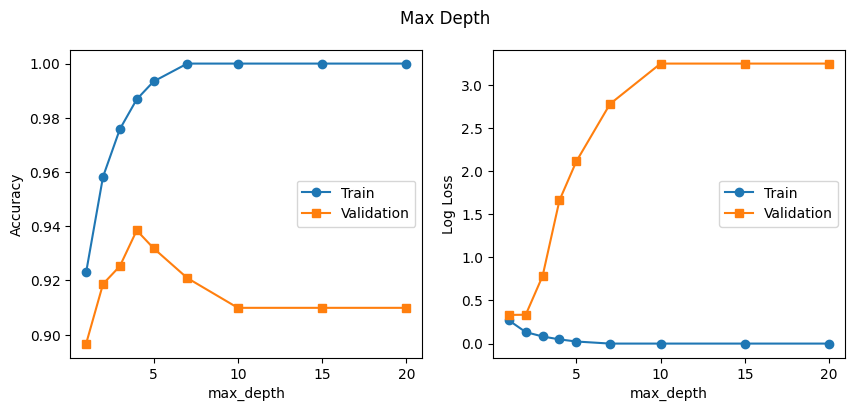

,max_depth,train_accuracy,val_accuracy,val_accuracy_std,train_log_loss,val_log_loss,val_log_loss_std
0,1.0,0.9231,0.8967,0.0192,0.2691,0.3323,0.0526
1,2.0,0.9582,0.9187,0.0192,0.1331,0.3347,0.1958
2,3.0,0.9758,0.9253,0.0245,0.0825,0.7840,0.3241
3,4.0,0.9868,0.9385,0.0179,0.0486,1.6614,0.7624
4,5.0,0.9934,0.9319,0.0213,0.0241,2.1125,0.8210
5,7.0,1.0000,0.9209,0.0213,-0.0000,2.7796,0.8244
6,10.0,1.0000,0.9099,0.0189,-0.0000,3.2479,0.6814
7,15.0,1.0000,0.9099,0.0189,-0.0000,3.2479,0.6814
8,20.0,1.0000,0.9099,0.0189,-0.0000,3.2479,0.6814
9,NaN,1.0000,0.9099,0.0189,-0.0000,3.2479,0.6814


In [15]:
max_depth_values=[1, 2, 3, 4, 5, 7, 10, 15, 20, None]
depth_labels=["1", "2", "3", "4", "5", "7", "10", "15", "20", "None"]
df_max_depth,_=evaluate_hyperparameter("max_depth", max_depth_values, depth_labels)
plot_hyperparameter_results(df_max_depth, "max_depth", "Max Depth")
df_max_depth.round(4)


Max Leaf Nodes


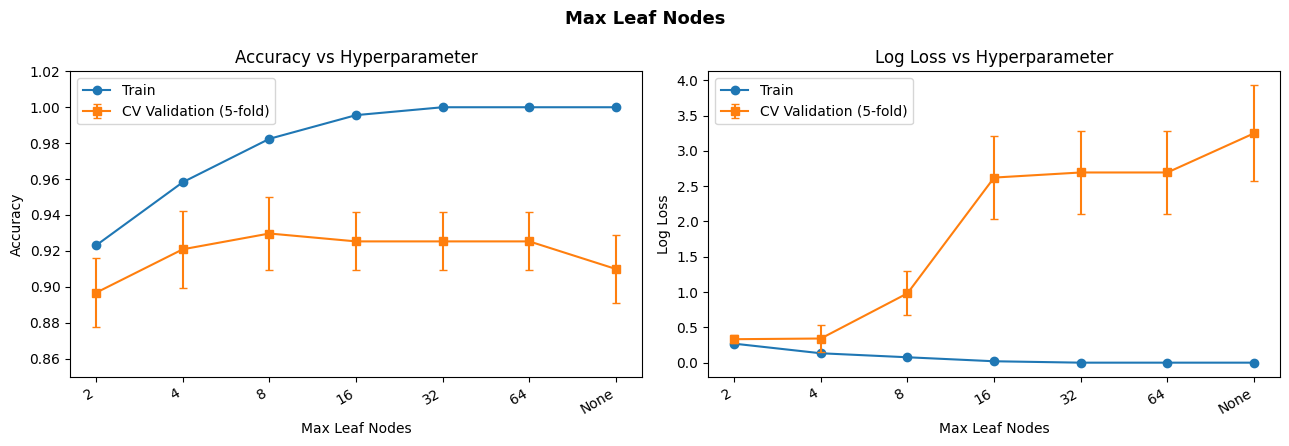

,max_leaf_nodes,train_accuracy,val_accuracy,val_accuracy_std,train_log_loss,val_log_loss,val_log_loss_std
0,2.0,0.9231,0.8967,0.0192,0.2691,0.3323,0.0526
1,4.0,0.9582,0.9209,0.0213,0.1331,0.3419,0.1902
2,8.0,0.9824,0.9297,0.0204,0.0764,0.9822,0.3105
3,16.0,0.9956,0.9253,0.0162,0.0199,2.6212,0.5904
4,32.0,1.0000,0.9253,0.0162,-0.0000,2.6934,0.5821
5,64.0,1.0000,0.9253,0.0162,-0.0000,2.6934,0.5821
6,NaN,1.0000,0.9099,0.0189,-0.0000,3.2479,0.6814


In [ ]:
max_leaf_values=[2, 4, 8, 16, 32, 64, None]
leaf_labels=["2", "4", "8", "16", "32", "64", "None"]
df_max_leaf,_=evaluate_hyperparameter("max_leaf_nodes", max_leaf_values, leaf_labels)
plot_hyperparameter_results(df_max_leaf, "max_leaf_nodes", "Max Leaf Nodes", x_labels=leaf_labels)
df_max_leaf.round(4)


Min Samples Split


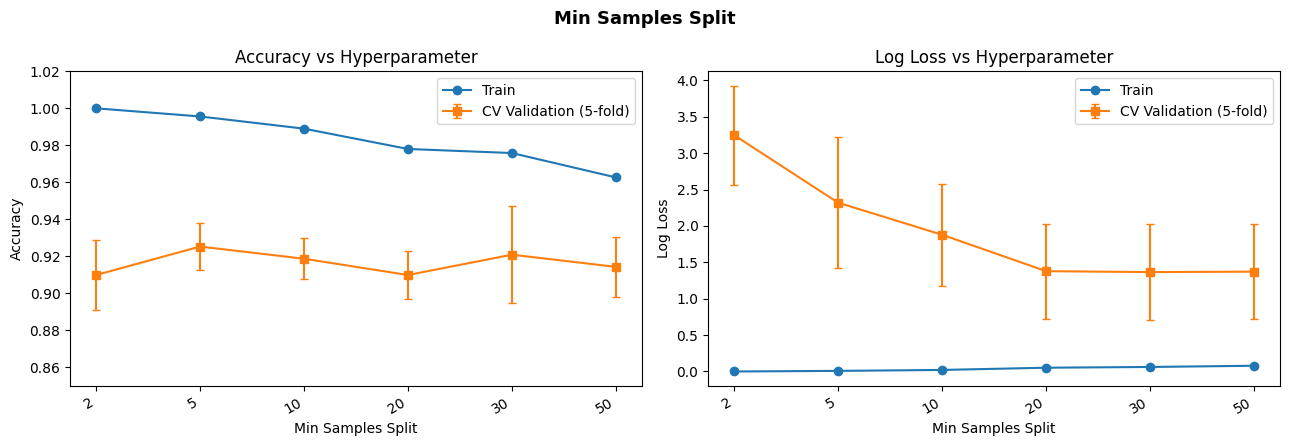

,min_samples_split,train_accuracy,val_accuracy,val_accuracy_std,train_log_loss,val_log_loss,val_log_loss_std
0,2,1.0000,0.9099,0.0189,-0.0000,3.2479,0.6814
1,5,0.9956,0.9253,0.0128,0.0084,2.3199,0.8974
2,10,0.9890,0.9187,0.0112,0.0213,1.8795,0.7030
3,20,0.9780,0.9099,0.0128,0.0519,1.3790,0.6513
4,30,0.9758,0.9209,0.0264,0.0622,1.3664,0.6609
5,50,0.9626,0.9143,0.0162,0.0790,1.3725,0.6561


In [ ]:
df_min_split, _ = evaluate_hyperparameter("min_samples_split", [2, 5, 10, 20, 30, 50])
plot_hyperparameter_results(df_min_split, "min_samples_split", "Min Samples Split")
df_min_split.round(4)


Min Samples Leaf


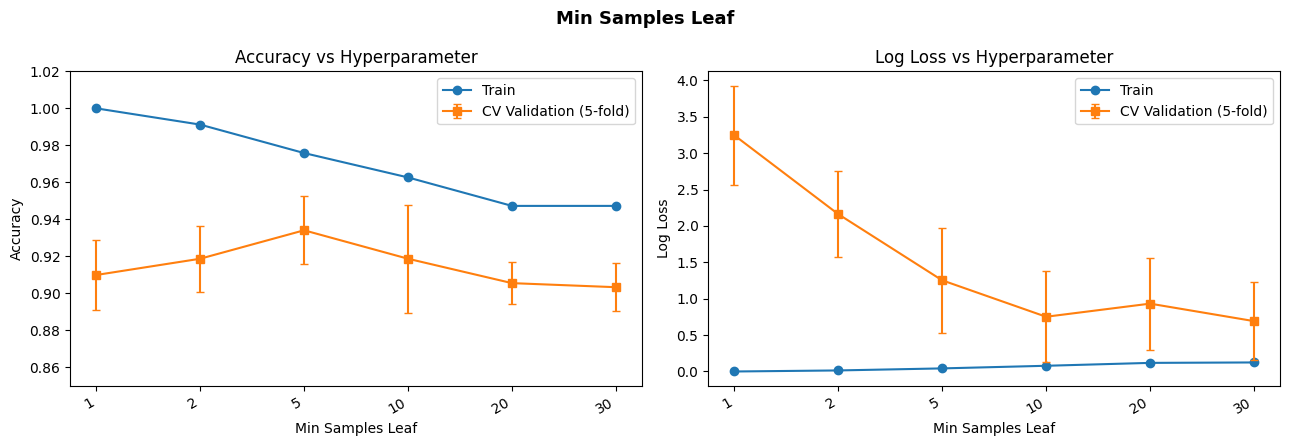

,min_samples_leaf,train_accuracy,val_accuracy,val_accuracy_std,train_log_loss,val_log_loss,val_log_loss_std
0,1,1.0000,0.9099,0.0189,-0.0000,3.2479,0.6814
1,2,0.9912,0.9187,0.0179,0.0145,2.1635,0.5903
2,5,0.9758,0.9341,0.0184,0.0425,1.2536,0.7246
3,10,0.9626,0.9187,0.0292,0.0785,0.7523,0.6250
4,20,0.9473,0.9055,0.0112,0.1184,0.9327,0.6321
5,30,0.9473,0.9033,0.0128,0.1243,0.6923,0.5337


In [ ]:
df_min_leaf, _=evaluate_hyperparameter("min_samples_leaf", [1, 2, 5, 10, 20, 30])
plot_hyperparameter_results(df_min_leaf, "min_samples_leaf", "Min Samples Leaf")
df_min_leaf.round(4)
